## This notebook is used to explore SHAP values explainable library for Python (Make sure you use 11.3 LTS cluster only)

In [0]:
pip install shap

Python interpreter will be restarted.
  Attempting uninstall: numpy
    Found existing installation: numpy 1.20.3
    Not uninstalling numpy at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-b157677b-f843-43a6-9c8f-5db4898a2d38
    Can't uninstall 'numpy'. No files were found to uninstall.
Python interpreter will be restarted.


In [0]:
pip install typing_extensions --upgrade

Python interpreter will be restarted.
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 3.10.0.2
    Not uninstalling typing-extensions at /databricks/python3/lib/python3.9/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-b157677b-f843-43a6-9c8f-5db4898a2d38
    Can't uninstall 'typing-extensions'. No files were found to uninstall.
Python interpreter will be restarted.


In [0]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pyspark.sql.functions as F
from delta.tables import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [0]:
write_path = 'dbfs:/tmp/reproducible_ml_uofl/medinsurance_linearreg_class1.delta'
medins_chrgs = spark.read.format('delta').load(write_path).toPandas()
medins_chrgs

,age,bmi,children,region,charges,gender_cd,smoker_cd
0,19,27.900,0,southwest,16884.92400,1,1
1,18,33.770,1,southeast,1725.55230,0,0
2,28,33.000,3,southeast,4449.46200,0,0
3,33,22.705,0,northwest,21984.47061,0,0
4,32,28.880,0,northwest,3866.85520,0,0
...,...,...,...,...,...,...,...
1333,50,30.970,3,northwest,10600.54830,0,0
1334,18,31.920,0,northeast,2205.98080,1,0
1335,18,36.850,0,southeast,1629.83350,1,0
1336,21,25.800,0,southwest,2007.94500,1,0


In [0]:
## Split the data into training and test sets. (0.75, 0.25) split.
seed = 123456789
train, test = train_test_split(medins_chrgs, train_size=0.75, random_state=seed)

## The target column is "quality" which is a scalar from [3, 9]
X_train = train.drop(['charges','region'], axis=1)
X_test = test.drop(['charges','region'], axis=1)
Y_train = train[['charges']]
Y_test = test[['charges']]

In [0]:
rf_reg = RandomForestRegressor(max_depth=6, random_state=0, n_estimators=10)
rf_reg.fit(X_train, Y_train.values.ravel())  

Out[5]: RandomForestRegressor(max_depth=6, n_estimators=10, random_state=0)

In [0]:
# Get the predictions and put them with the test data.
X_output = X_test.copy()
X_output.loc[:,'predict'] = np.round(rf_reg.predict(X_test),2)

# Sort by highest to lowest predicted probability 
X_output_sorted= X_output.sort_values('predict',ascending=False)

In [0]:
import shap
X_test_new = X_output_sorted.drop(['predict'], axis=1)
wfall_exapliner = shap.Explainer(rf_reg, X_test_new)
shap_values_waterfall = wfall_exapliner(X_test_new)
print(shap_values_waterfall.base_values.mean())

14955.205159556937


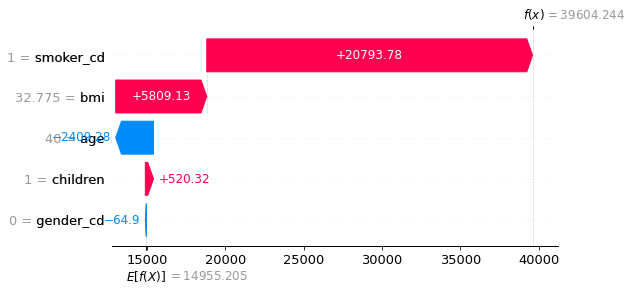

In [0]:
shap.plots.waterfall(shap_values_waterfall[24], max_display=20)

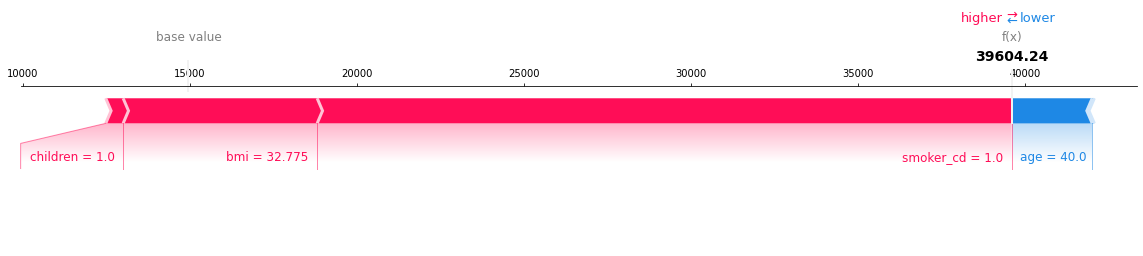

In [0]:
shap.plots.force(shap_values_waterfall[24], matplotlib=True)

In [0]:
column_names = X_test_new.columns.values.tolist()
column_names

Out[10]: ['age', 'bmi', 'children', 'gender_cd', 'smoker_cd']

In [0]:
shap_values_waterfall[24]

Out[11]: .values =
array([-2409.28216827,  5809.1253558 ,   520.32004162,   -64.9045367 ,
       20793.78037476])

.base_values =
14955.205159556936

.data =
array([40.   , 32.775,  1.   ,  0.   ,  1.   ])


## Assignment 3.2

1. Use your unique number for seed (maybe use combination derived from your phone number) and 10 estimators to build the model
1. Use the place of first letter from your first name in english alphabet list (Remember there are 26 alphabets in English from A-Z) to identify a record and show that record's waterfall plot, force plot, and actual SHAP values e.g. H is the first letter in Harpreet and H is 8th alpahabet in english alphabet list so I will pick the 8th record for this solution, L is the first letter in Lance and L is the 12th alphabet in english alphabet list so Lance will pick the 12th highest scored record to show the plots 
NOTE: Make sure you write down your first name at the end of the notebook either in a Commented cell or a Markdown cell like this one